In [37]:
"""
Dry compaction module (HS2SWE vs ΔSNOW) — minimal + structured

What this script does (once, in a sensible order):
1) Defines both single-layer compaction step functions.
2) Runs a small experiment for multiple overburden stress levels and TWO initial densities.
3) Produces ONE figure:
   - 2x4 panel grid (Light + Dense) with HS, rho, SWE, settling rate S=σ/η
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec


# ============================================================
# USER SETTINGS (single source of truth for parameters)
# ============================================================
DT_S = 86400.0
N_DAYS = 60
T_DAYS = np.arange(N_DAYS)
N_DAYS_NEW_TRY = 100

G = 9.81

# Stress levels (Pa = N/m^2)
SIGMA_LEVELS = np.array([100, 1000, 10000], dtype=float)
SIGMA_LEVELS_REL = np.array([357], dtype=float)

# Initial conditions
HS0_CM = 50.0
SNOTEMP = 0.0

# Calibrated ΔSNOW parameters (from optimization output)
rho_max   = 307.9931753
rho_null  = 90.54167687
c_ov      = 0.0005846939387
k_ov      = 0.2819007367
k         = 0.0284092879
tau       = 0.02310599162
eta_null  = 8967842.191

# ΔSNOW parameters used in this notebook
ETA0_DS = eta_null
K_DS = k
RHO_MAX_DS = rho_max
RHO0_DS = rho_null

# HS2SWE parameters used in this notebook
ETA0_HS = 6.051e7
C1 = 2.8e-6
C2 = 0.042
C3 = 0.046
C4 = 0.081
C5 = 0.018
RHO_NEW_HS = 113.7
RHO_MAX_HS = 571.6
RHO0_HS = 113.0

# Compatibility aliases for existing functions/cells
VISC_HS = ETA0_HS
C5_HS = C5
c1 = C1
c3 = C3

# Plot comparison overburden
OVB = 100.0

# Two start-density configs for the 2x4 comparison panel
RHO0_CONFIGS = {
    "avg snow": 200,
    "Dense snow": 300,
}

# ============================================================
# Globals to store the last computed HS2SWE terms
# ============================================================
HS2SWE_TERM_OVB = np.nan
HS2SWE_TERM_METAMORPH = np.nan



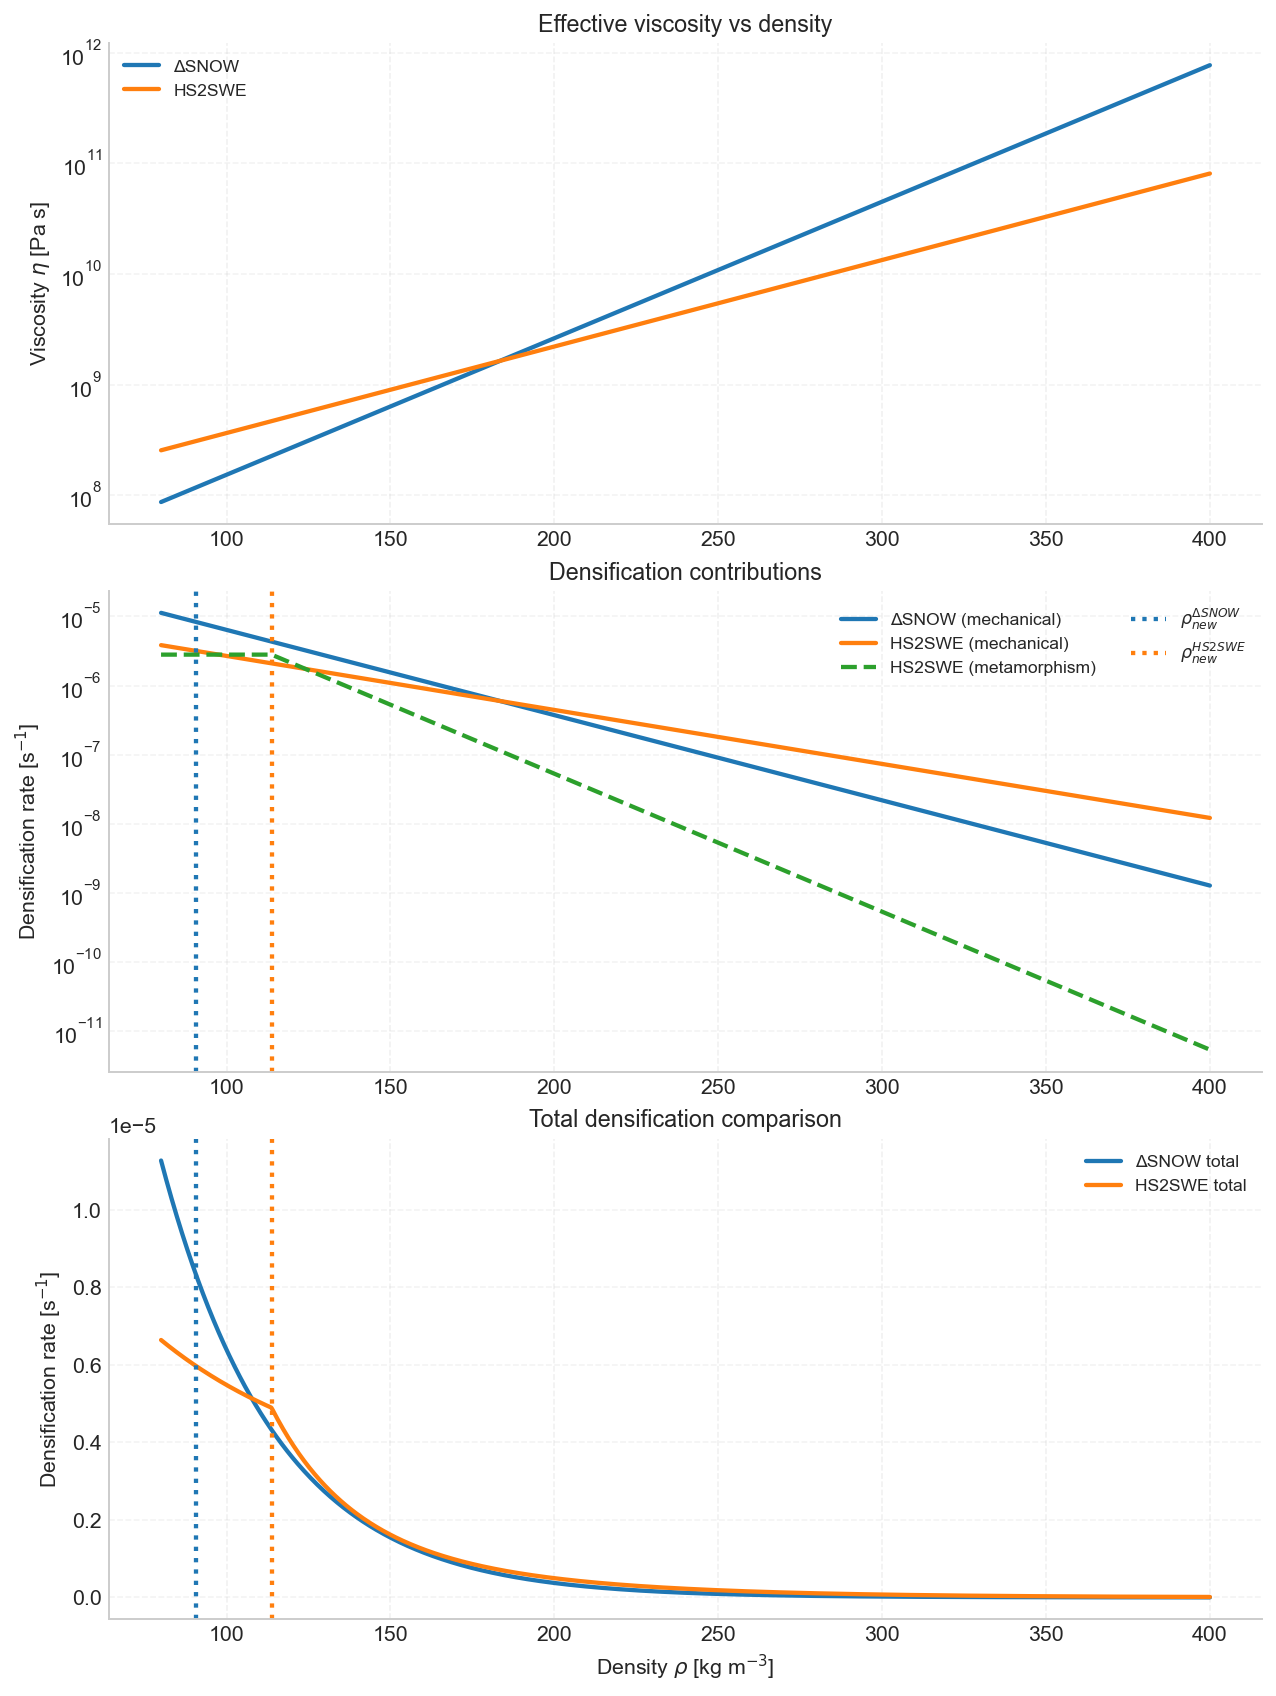

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# PARAMETERS (reused from top-level settings in Cell 1)
# ============================================================
rho = np.linspace(80, 400, 800)

# Use globally defined notebook parameters
rho_new_dsnow = RHO0_DS   # shown as reference line
RHO_NEW_hs2swe = RHO_NEW_HS

# ============================================================
# MODEL FUNCTIONS
# ============================================================

eta_ds = ETA0_DS * np.exp(K_DS * rho)
eta_hs = ETA0_HS * np.exp(C5 * rho)

D_ds_mech = OVB * G / eta_ds
D_hs_mech = OVB * G / eta_hs

D_hs_meta = C1 * np.exp(-C3 * np.maximum(0.0, rho - RHO_NEW_hs2swe))

D_ds_total = D_ds_mech
D_hs_total = D_hs_mech + D_hs_meta

# ============================================================
# STYLE
# ============================================================

mpl.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(3, 1, figsize=(9, 12), constrained_layout=True)

# ============================================================
# (1) VISCOSITY
# ============================================================
ax = axes[0]
ax.plot(rho, eta_ds, label="ΔSNOW")
ax.plot(rho, eta_hs, label="HS2SWE")
ax.set_yscale("log")
ax.set_ylabel(r"Viscosity $\eta$ [Pa s]")
ax.set_title("Effective viscosity vs density")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)

# ============================================================
# (2) CONTRIBUTIONS
# ============================================================
ax = axes[1]
ax.plot(rho, D_ds_mech, label="ΔSNOW (mechanical)")
ax.plot(rho, D_hs_mech, label="HS2SWE (mechanical)")
ax.plot(rho, D_hs_meta, linestyle="--", label="HS2SWE (metamorphism)")

ax.axvline(rho_new_dsnow, color="tab:blue", linestyle=":", label=r"$\rho_{new}^{\Delta SNOW}$")
ax.axvline(RHO_NEW_hs2swe, color="tab:orange", linestyle=":", label=r"$\rho_{new}^{HS2SWE}$")

ax.set_yscale("log")

ax.set_ylabel(r"Densification rate [s$^{-1}$]")
ax.set_title("Densification contributions")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.25)

# ============================================================
# (3) TOTAL COMPARISON
# ============================================================
ax = axes[2]
ax.plot(rho, D_ds_total, label="ΔSNOW total")
ax.plot(rho, D_hs_total, label="HS2SWE total")

ax.axvline(rho_new_dsnow, color="tab:blue", linestyle=":")
ax.axvline(RHO_NEW_hs2swe, color="tab:orange", linestyle=":")



ax.set_xlabel(r"Density $\rho$ [kg m$^{-3}$]")
ax.set_ylabel(r"Densification rate [s$^{-1}$]")
ax.set_title("Total densification comparison")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)

plt.show()

# New try

In [39]:
# Parameters are defined once in Cell 1.
# This cell only prints the active parameter set for quick verification.

print("Active parameter set from Cell 1:")
print(f"rho_max   = {rho_max}")
print(f"rho_null  = {rho_null}")
print(f"c_ov      = {c_ov}")
print(f"k_ov      = {k_ov}")
print(f"k         = {k}")
print(f"tau       = {tau}")
print(f"eta_null  = {eta_null}")

Active parameter set from Cell 1:
rho_max   = 307.9931753
rho_null  = 90.54167687
c_ov      = 0.0005846939387
k_ov      = 0.2819007367
k         = 0.0284092879
tau       = 0.02310599162
eta_null  = 8967842.191


Initial sigma ΔSNOW  = 399.70 Pa
Initial sigma HS2SWE = 498.84 Pa


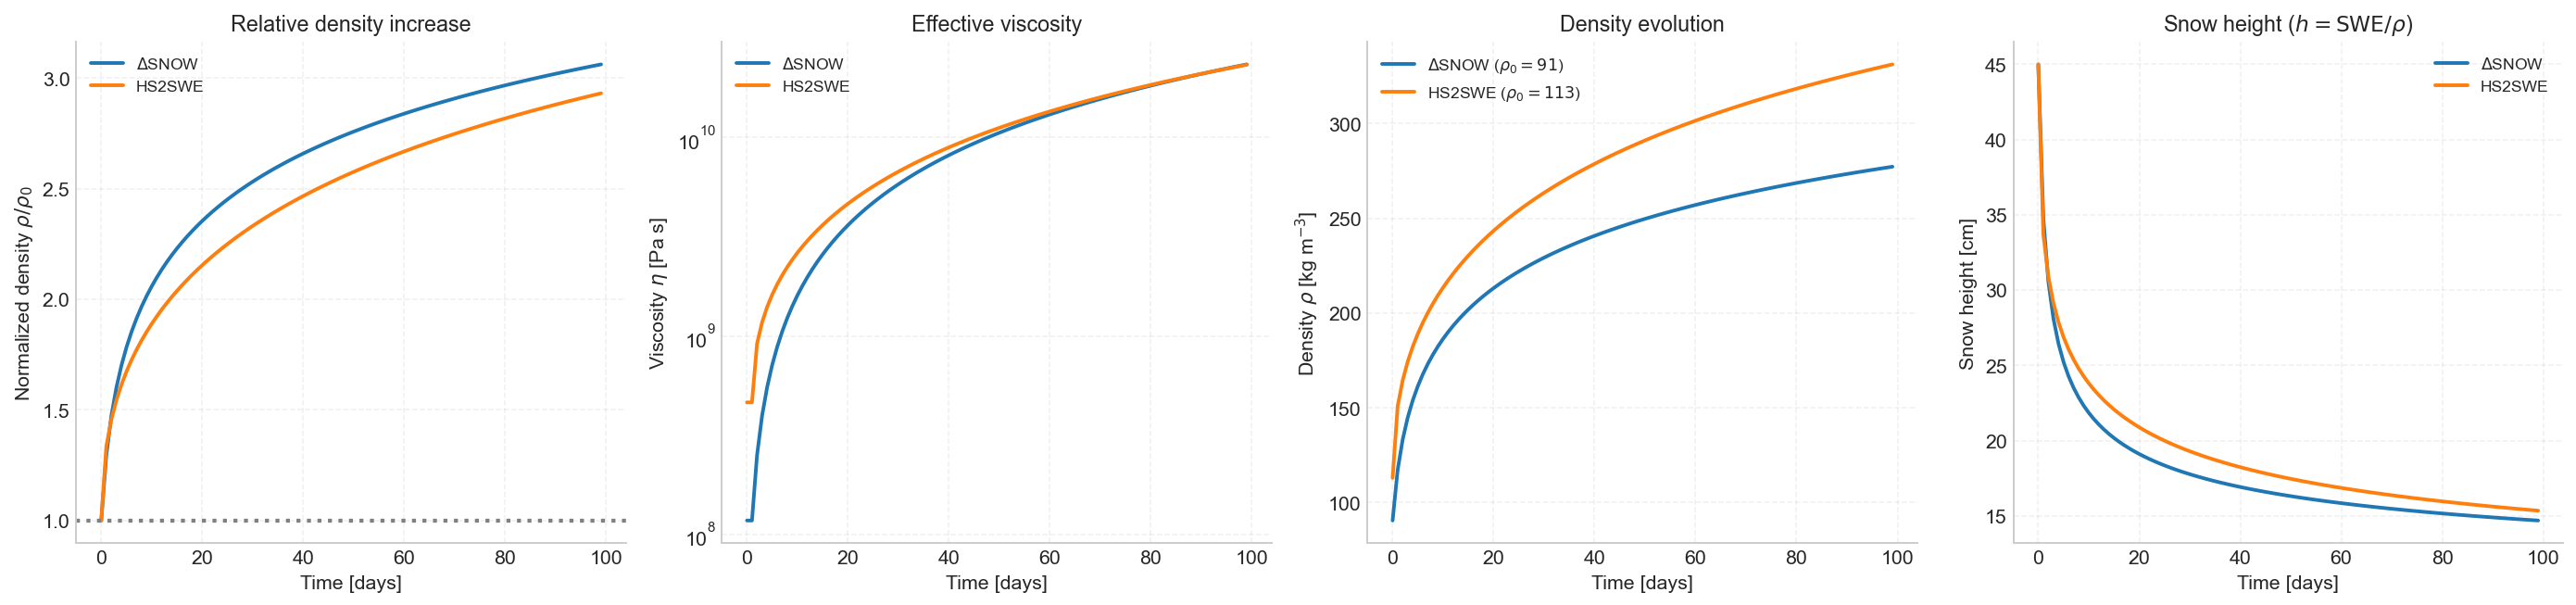

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS (reused from top-level settings in Cell 1)
# ============================================================
HS0_M = HS0_CM / 100.0

# ============================================================
# MODEL EQUATIONS IN DENSITY FORM
# sigma = SWE * g
# SWE = hs[m] * rho
# ============================================================
def dsnow_rho_step(rho, hs_m, dt_s=DT_S, g=G,
                   eta0=ETA0_DS, k=K_DS, rho_max=RHO_MAX_DS):
    swe = hs_m * rho                     # kg m^-2
    sigma = swe * g                      # Pa
    eta = eta0 * np.exp(k * rho)

    rho_new = rho * (1.0 + dt_s * sigma / eta)
    rho_new = min(rho_new, rho_max)

    # SWE conserved -> hs changes accordingly
    hs_new = swe / rho_new
    return hs_new, rho_new, eta, sigma


def hs2swe_rho_step(rho, hs_m, Ts=SNOTEMP, dt_s=DT_S, g=G,
                    eta0=ETA0_HS, c1=C1, c2=C2, c3=C3,
                    c4=C4, c5=C5, rho_new_ref=RHO_NEW_HS,
                    rho_max=RHO_MAX_HS):
    swe = hs_m * rho                     # kg m^-2
    sigma = swe * g                      # Pa

    eta = eta0 * np.exp(c4 * Ts + c5 * rho)

    term_overburden = sigma / eta
    term_metamorph = c1 * np.exp(-c2 * Ts - c3 * max(0.0, rho - rho_new_ref))

    rho_new = rho * (1.0 + dt_s * (term_overburden + term_metamorph))
    rho_new = min(rho_new, rho_max)

    hs_new = swe / rho_new
    return hs_new, rho_new, eta, sigma, term_overburden, term_metamorph


# ============================================================
# RUN BOTH MODELS
# ============================================================
def run_models(n_days=N_DAYS_NEW_TRY, hs0_cm=45.0, rho0_ds=RHO0_DS, rho0_hs=RHO0_HS,
               Ts=SNOTEMP, dt_s=DT_S, g=G):

    hs_ds = np.zeros(n_days)
    rho_ds = np.zeros(n_days)
    eta_ds = np.zeros(n_days)
    sigma_ds = np.zeros(n_days)

    hs_hs = np.zeros(n_days)
    rho_hs = np.zeros(n_days)
    eta_hs = np.zeros(n_days)
    sigma_hs = np.zeros(n_days)
    meta_hs = np.zeros(n_days)
    ovb_hs = np.zeros(n_days)

    hs_ds[0] = hs0_cm / 100.0
    rho_ds[0] = rho0_ds
    sigma_ds[0] = hs_ds[0] * rho_ds[0] * g
    eta_ds[0] = ETA0_DS * np.exp(K_DS * rho_ds[0])

    hs_hs[0] = hs0_cm / 100.0
    rho_hs[0] = rho0_hs
    sigma_hs[0] = hs_hs[0] * rho_hs[0] * g
    eta_hs[0] = ETA0_HS * np.exp(C4 * Ts + C5 * rho_hs[0])
    ovb_hs[0] = sigma_hs[0] / eta_hs[0]
    meta_hs[0] = C1 * np.exp(-C2 * Ts - C3 * max(0.0, rho_hs[0] - RHO_NEW_HS))

    for i in range(1, n_days):
        hs_ds[i], rho_ds[i], eta_ds[i], sigma_ds[i] = dsnow_rho_step(
            rho_ds[i-1], hs_ds[i-1], dt_s=dt_s, g=g,
            eta0=ETA0_DS, k=K_DS, rho_max=RHO_MAX_DS
        )

        hs_hs[i], rho_hs[i], eta_hs[i], sigma_hs[i], ovb_hs[i], meta_hs[i] = hs2swe_rho_step(
            rho_hs[i-1], hs_hs[i-1], Ts=Ts, dt_s=dt_s, g=g,
            eta0=ETA0_HS, c1=C1, c2=C2, c3=C3, c4=C4, c5=C5,
            rho_new_ref=RHO_NEW_HS, rho_max=RHO_MAX_HS
        )

    return {
        "hs_ds": hs_ds,
        "rho_ds": rho_ds,
        "eta_ds": eta_ds,
        "sigma_ds": sigma_ds,
        "rho_norm_ds": rho_ds / rho0_ds,

        "hs_hs": hs_hs,
        "rho_hs": rho_hs,
        "eta_hs": eta_hs,
        "sigma_hs": sigma_hs,
        "rho_norm_hs": rho_hs / rho0_hs,
        "ovb_hs": ovb_hs,
        "meta_hs": meta_hs,
    }


# ============================================================
# PLOT
# ============================================================
def plot_results(res):
    t_days = np.arange(len(res["rho_ds"]))
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))

    # 1) normalized density
    axes[0].plot(t_days, res["rho_norm_ds"], label=r"$\Delta$SNOW", lw=2)
    axes[0].plot(t_days, res["rho_norm_hs"], label="HS2SWE", lw=2)
    axes[0].axhline(1.0, color="0.5", ls=":")
    axes[0].set_xlabel("Time [days]")
    axes[0].set_ylabel(r"Normalized density $\rho / \rho_0$")
    axes[0].set_title("Relative density increase")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # 2) viscosity
    axes[1].plot(t_days, res["eta_ds"], label=r"$\Delta$SNOW", lw=2)
    axes[1].plot(t_days, res["eta_hs"], label="HS2SWE", lw=2)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Time [days]")
    axes[1].set_ylabel(r"Viscosity $\eta$ [Pa s]")
    axes[1].set_title("Effective viscosity")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # 3) density
    axes[2].plot(t_days, res["rho_ds"], label=rf"$\Delta$SNOW ($\rho_0={RHO0_DS:.0f}$)", lw=2)
    axes[2].plot(t_days, res["rho_hs"], label=rf"HS2SWE ($\rho_0={RHO0_HS:.0f}$)", lw=2)
    axes[2].set_xlabel("Time [days]")
    axes[2].set_ylabel(r"Density $\rho$ [kg m$^{-3}$]")
    axes[2].set_title("Density evolution")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # 4) snow height (CONSISTENT via SWE/rho)
    hs_ds_cm = res["hs_ds"] * 100.0
    hs_hs_cm = res["hs_hs"] * 100.0

    axes[3].plot(t_days, hs_ds_cm, label=r"$\Delta$SNOW", lw=2)
    axes[3].plot(t_days, hs_hs_cm, label="HS2SWE", lw=2)

    axes[3].set_xlabel("Time [days]")
    axes[3].set_ylabel("Snow height [cm]")
    axes[3].set_title(r"Snow height ($h = \mathrm{SWE}/\rho$)")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================
res = run_models(
    n_days=N_DAYS_NEW_TRY,
    hs0_cm=45.0,
    rho0_ds=RHO0_DS,
    rho0_hs=RHO0_HS,
    Ts=SNOTEMP,
    dt_s=DT_S,
    g=G,
 )

print(f"Initial sigma ΔSNOW  = {res['sigma_ds'][0]:.2f} Pa")
print(f"Initial sigma HS2SWE = {res['sigma_hs'][0]:.2f} Pa")

plot_results(res)